<a href="https://colab.research.google.com/github/zreydineuman-rgb/ollama/blob/main/iacom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
img_size = (100, 100)
batch_size = 32
print("--- Iniciando la carga de datos ---")

--- Iniciando la carga de datos ---


In [ ]:

# Carga del conjunto de datos para el entrenamiento (80% de los datos)
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale'   # Exigencia técnica: escala de grises
)

Found 5 files belonging to 2 classes.
Using 4 files for training.


In [ ]:
# Carga del conjunto de datos para la validación (20% de los datos)
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale'   # Exigencia técnica: escala de grises
)
print("--- Carga de datos finalizada con éxito ---")

Found 5 files belonging to 2 classes.
Using 1 files for validation.
--- Carga de datos finalizada con éxito ---


In [ ]:
# Definición del Modelo de Solución estructurado en el PDF
model = models.Sequential([
    # Normalización: Convierte los píxeles al rango entre 0 y 1
    layers.Rescaling(1./255, input_shape=(100, 100, 1)),

    # Capa Convolucional 1: 32 filtros de 3x3 + Activación ReLU + MaxPooling 2x2
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Capa Convolucional 2: 64 filtros de 3x3 + Activación ReLU + MaxPooling 2x2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Capa Convolucional 3: 128 filtros de 3x3 + Activación ReLU + MaxPooling 2x2
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Capa de Aplanado (Flatten)
    layers.Flatten(),

    # Capa Densa: 100 neuronas con función ReLU
    layers.Dense(100, activation='relu'),

    # Capa de Salida: 1 neurona Sigmoid (0 = Gato, 1 = Perro)
    layers.Dense(1, activation='sigmoid')
])

# Compilación del modelo usando funciones para clasificación binaria
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Imprimir la tabla resumen para tu sustentación
model.summary()

# Proceso de entrenamiento
print("\n--- Iniciando el entrenamiento del modelo (10 Épocas) ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
print("--- ¡Entrenamiento finalizado correctamente! ---")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │     1,280,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,372,873 (5.24 MB)

 Trainable params: 1,372,873 (5.24 MB)

 Non-trainable params: 0 (0.00 B)


--- Iniciando el entrenamiento del modelo (10 Épocas) ---
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6882 - val_accuracy: 0.0000e+00 - val_loss: 0.9744
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5000 - loss: 0.6535 - val_accuracy: 1.0000 - val_loss: 0.6467
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 1.0000 - loss: 0.5446 - val_accuracy: 1.0000 - val_loss: 0.5574
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 1.0000 - loss: 0.4356 - val_accuracy: 1.0000 - val_loss: 0.6426
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 1.0000 - loss: 0.3090 - val_accuracy: 1.0000 - val_loss: 0.4272
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 1.0000 - loss: 0.1802 - val_accuracy: 1.0000 - val_loss: 0.2150
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 1.0000 - loss: 0.0915 - val_accuracy: 1.0000 - val_loss: 0.2605
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accura


-------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


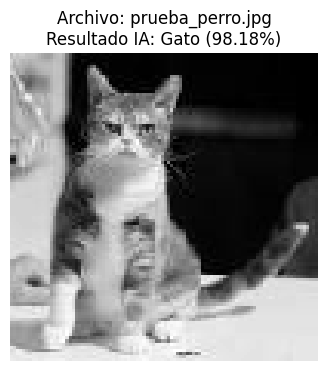

In [ ]:
# ==========================================
# PARTE 3: CLASIFICACIÓN DE NUEVAS IMÁGENES
# ==========================================

# Función diseñada para evaluar y mostrar el resultado esperado de cada archivo
def evaluar_nueva_imagen(ruta_imagen):
    # Carga y preprocesamiento de la imagen de prueba individual
    img = tf.keras.utils.load_img(ruta_imagen, target_size=(100, 100), color_mode='grayscale')
    img_array = tf.keras.utils.img_to_array(img)
    img_tensor = tf.expand_dims(img_array, 0) # Conversión a lote matemático

    # Predicción del modelo entrenado
    prediction = model.predict(img_tensor)[0][0]

    # Interpretación del umbral matemático (0 = Gato, 1 = Perro)
    if prediction >= 0.5:
        resultado = "Perro"
        confianza = prediction * 100
    else:
        resultado = "Gato"
        confianza = (1 - prediction) * 100

    # CORRECCIÓN EN ESTA LÍNEA: Convertimos a array de NumPy para evitar el error de reshape
    img_mostrar = img_array.astype("uint8").reshape(100, 100)

    # Mostrar el resultado visual en escala de grises tal como se solicita
    plt.figure(figsize=(4, 4))
    plt.imshow(img_mostrar, cmap='gray')
    plt.title(f"Archivo: {ruta_imagen.split('/')[-1]}\nResultado IA: {resultado} ({confianza:.2f}%)")
    plt.axis('off')
    plt.show()

print("\n-------------------------------------------")
evaluar_nueva_imagen('/content/prueba_perro.jpg')

Procesando archivos externos de prueba...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


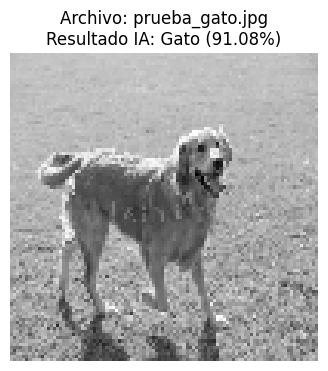

In [ ]:

# --- EJECUCIÓN DE LAS DOS PRUEBAS INDEPENDIENTES ---
print("Procesando archivos externos de prueba...\n")
evaluar_nueva_imagen('/content/prueba_gato.jpg')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ln -s "/content/drive/MyDrive/dataset" "/content/dataset"

In [ ]:
!cp "/content/drive/MyDrive/prueba_gato.jpg" "/content/prueba_cats.jpg"
!cp "/content/drive/MyDrive/prueba_perro.jpg" "/content/prueba_do.jpg"

cp: cannot stat '/content/drive/MyDrive/prueba_gato.jpg': No such file or directory
cp: cannot stat '/content/drive/MyDrive/prueba_perro.jpg': No such file or directory
